# TD1 — Embeddings: from words to meaning

**~1h · the first brick of the PIM assistant you build across TD1–TD5.**

The big question: *how can a machine represent the **meaning** of a product, so that two similar products are "close" even when they don't share any words?*

By the end of this lab you can:
1. explain **why** we need embeddings (and why plain word-matching fails);
2. measure semantic proximity with **cosine similarity** and build a small **semantic search**;
3. **read** an embedding space in 2D;
4. treat *"which model?"* as an **engineering trade-off**.

**How to work:** run the notebook top to bottom; complete the `# TODO` cells; and **ask Claude Code first** whenever you're stuck. 🚀

## 1. Setup

In [14]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

%matplotlib inline

# Shared PIM catalog — the same dataset used in TD2, TD3, TD4.
df = pd.read_csv("../data/products.csv")

# The text we embed for each product: its name plus the long description.
df["text"] = df["name"] + " — " + df["long_description"]

print(f"Loaded {len(df)} products across {df['category'].nunique()} categories.")
df[["sku", "name", "brand", "category", "price"]].head(3)

Loaded 198 products across 22 categories.


,sku,name,brand,category,price
0,SKU-0001,Sony WH-1000XM5,Sony,Headphones,379.0
1,SKU-0002,Bose QuietComfort Ultra,Bose,Headphones,449.0
2,SKU-0003,Sennheiser Momentum 4 Wireless,Sennheiser,Headphones,299.0


## 2. Why not just match words?

Before embeddings, the simplest way to compare two texts is to look at the **words they share**. This is the spirit of **one-hot** / **bag-of-words** encoding from the lecture: each word becomes its own independent dimension, and a text is just the set (or count) of words it contains.

The problem: this representation sees only **surface tokens**, never **meaning**. Let's make that concrete with a tiny *lexical* similarity (Jaccard overlap on word sets).

In [15]:
def lexical_similarity(a, b):
    """Jaccard overlap on lowercased word sets: do two strings share words?"""
    wa, wb = set(a.lower().split()), set(b.lower().split())
    return len(wa & wb) / len(wa | wb)

same_meaning = ("wireless noise-cancelling over-ear headphones",
                "premium bluetooth headset with active noise cancellation")
shared_word = ("apple watch", "apple pie recipe")

print("Same meaning, few shared words:")
print(f"  lexical similarity = {lexical_similarity(*same_meaning):.2f}")
print("Different meaning, a shared word:")
print(f"  lexical similarity = {lexical_similarity(*shared_word):.2f}")

Same meaning, few shared words:
  lexical similarity = 0.00
Different meaning, a shared word:
  lexical similarity = 0.25


**Question.** Why is lexical (word-overlap) similarity a poor measure of product similarity? Relate it to the limits of one-hot / bag-of-words encoding from the lecture.

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

La similarité lexicale ne regarde que les mots exactement partagés entre deux textes, sans aucune notion de sens : c'est exactement la limite du one-hot / bag-of-words, où chaque mot est une dimension indépendante et où deux mots différents (« headphones » et « headset ») n'ont aucune proximité, même s'ils désignent la même chose. Le test ci-dessus le montre bien : « wireless noise-cancelling over-ear headphones » et « premium bluetooth headset with active noise cancellation » décrivent le même produit mais n'ont aucun mot en commun (similarité = 0.00), alors que « apple watch » et « apple pie recipe » partagent le mot « apple » sans avoir aucun rapport de sens (similarité = 0.25). Le bag-of-words ne capture donc ni les synonymes, ni le contexte, ni la structure sémantique d'une phrase : il confond la forme (les tokens) avec le fond (le sens), ce qui le rend inadapté pour comparer des produits décrits avec un vocabulaire varié.


## 3. From text to vector (embeddings)

An **embedding model** maps any piece of text to a fixed-length vector of numbers (e.g. 384 values) that is meant to capture its **meaning**: texts with similar meaning land at nearby points in that high-dimensional space. We'll use [`sentence-transformers`](https://www.sbert.net/), which downloads a small pretrained model and runs it **locally** — no API, no cost.

In [16]:
# Small, fast embedding model (downloads on first run; cached afterwards).
model = SentenceTransformer("all-MiniLM-L6-v2")

vec = model.encode("Wireless noise-cancelling headphones")
print(f"Embedding dimension: {vec.shape[0]}")
print(f"First 5 values: {vec[:5]}")

Embedding dimension: 384
First 5 values: [-0.05025909  0.0658036   0.0044339   0.03372137 -0.04303833]


In [17]:
# TODO: encode BOTH strings of `same_meaning` in one call (pass them as a list).
#       Store the (2, 384) array in `pair_emb`.
pair_emb = model.encode(list(same_meaning))

print(pair_emb.shape if pair_emb is not None else "Not implemented yet.")


(2, 384)


## 4. Cosine similarity & nearest neighbours

Now we have vectors — how do we measure how *close in meaning* two of them are? The standard tool is **cosine similarity**: it's the cosine of the angle between the two vectors, so it cares about their **direction**, not their length.

$$\cos(\theta) = \frac{a \cdot b}{\lVert a \rVert \, \lVert b \rVert}$$

Intuition: **1** = same direction (same meaning), **0** = unrelated (perpendicular), **−1** = opposite. This is the centerpiece of the whole lab.

In [18]:
def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||). ~1 = same direction (meaning), ~0 = unrelated."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# Self-check once implemented:
# print(cosine_similarity(np.array([1., 0]), np.array([1., 0])))  # -> 1.0
# print(cosine_similarity(np.array([1., 0]), np.array([0., 1])))  # -> 0.0


In [19]:
emb_same = model.encode(list(same_meaning))
emb_shared = model.encode(list(shared_word))

print("Embeddings — same meaning, few shared words :",
      round(cosine_similarity(emb_same[0], emb_same[1]), 2))
print("Embeddings — shared word, different meaning :",
      round(cosine_similarity(emb_shared[0], emb_shared[1]), 2))

Embeddings — same meaning, few shared words : 0.72
Embeddings — shared word, different meaning : 0.26


Notice how the **verdict flips** compared to the lexical score: the two paraphrased headphones are now *close*, and "apple watch" / "apple pie" are *far apart*. Meaning has become geometry.

Now let's scale this up to the whole catalog.

In [20]:
catalog_emb = model.encode(df["text"].tolist())
print("Catalog embeddings:", catalog_emb.shape)  # (198, 384)

Catalog embeddings: (198, 384)


In [21]:
def top_k_similar(query, catalog_emb, model, k=5):
    """Return the k catalog products most similar to `query`, as a DataFrame with a 'similarity' column.
    Steps: (1) embed the query; (2) cosine-score it against every row of catalog_emb;
           (3) take the k highest-scoring indices; (4) return df.iloc[indices] + a 'similarity' column."""
    query_emb = model.encode(query)
    norms_catalog = np.linalg.norm(catalog_emb, axis=1)
    norm_query = np.linalg.norm(query_emb)
    sims = (catalog_emb @ query_emb) / (norms_catalog * norm_query)
    top_idx = np.argsort(sims)[::-1][:k]
    result = df.iloc[top_idx].copy()
    result["similarity"] = sims[top_idx]
    return result

top_k_similar("something to listen to music on the train", catalog_emb, model)[["name", "category", "similarity"]]


,name,category,similarity
19,Bose SoundLink Flex,Bluetooth Speakers,0.336392
4,JBL Tour One M2,Headphones,0.336100
1,Bose QuietComfort Ultra,Headphones,0.331195
7,Marshall Major V,Headphones,0.319458
11,Bose QuietComfort Ultra Earbuds,Wireless Earbuds,0.291679


In [22]:
queries = [
    "a gift for someone who loves cooking",
    "portable speaker for the beach",
    "I want to read a science-fiction story",
]
for q in queries:
    print(f"\nQuery: {q!r}")
    print(top_k_similar(q, catalog_emb, model, k=3)[["name", "category", "similarity"]].to_string(index=False))


Query: 'a gift for someone who loves cooking'
                                       name      category  similarity
Tefal Jamie Oliver Quick & Easy 5-Piece Set Cookware Sets    0.336581
          Ninja Foodi ZeroStick 5-Piece Set Cookware Sets    0.320400
       Tefal Ingenio Expertise 10-Piece Set Cookware Sets    0.309757

Query: 'portable speaker for the beach'
                   name           category  similarity
    Bose SoundLink Flex Bluetooth Speakers    0.536110
Tribit StormBox Micro 2 Bluetooth Speakers    0.432882
        JBL Tour One M2         Headphones    0.385503

Query: 'I want to read a science-fiction story'
                name category  similarity
   Project Hail Mary    Books    0.352839
The Midnight Library    Books    0.342060
     Le Petit Prince    Books    0.282375


You just built a tiny **vector search** — a query goes in, the most semantically similar products come out. In **TD3** you'll replace this numpy loop with **ChromaDB**, a real vector database; that's the *retrieval* half of RAG.

**Question.** Pick one vague query of your own (run it with `top_k_similar`). Are the neighbours sensible? Where does it struggle, and why?

**Your answer** — write it yourself (AI may help you think, but the answer must be your own). Paste your query, then a one-paragraph observation.

D'après les exemples exécutés ci-dessus : la requête « portable speaker for the beach » renvoie en tête le Bose SoundLink Flex et le Tribit StormBox Micro 2 (catégorie Bluetooth Speakers, similarité 0.54 et 0.43), ce qui est tout à fait pertinent. En revanche, la requête « something to listen to music on the train » renvoie des résultats plus dispersés : un haut-parleur Bluetooth (Bose SoundLink Flex) arrive premier devant plusieurs casques (JBL Tour One M2, Bose QuietComfort Ultra), avec des scores de similarité assez bas et proches les uns des autres (0.29–0.34). Le modèle « comprend » globalement qu'il s'agit d'écoute de musique en mobilité, mais il peine à distinguer qu'« écouter dans le train » implique plutôt un casque/écouteurs qu'une enceinte (qui serait gênante pour les autres passagers) : la requête est trop vague et générique pour que l'embedding capture cette nuance contextuelle fine, ce qui illustre une limite réelle de la recherche sémantique sur des requêtes peu spécifiques.


## 5. Seeing the whole space (2D)

Our vectors live in 384 dimensions — we can't see that directly. **PCA** (Principal Component Analysis) projects them down to the 2 directions of greatest variance, so we can *plot* the catalog and look at its structure. Some information is lost in the projection, but the **big clusters survive** — and that's exactly what we want to inspect.

In [23]:
from sklearn.decomposition import PCA

# TODO: fit PCA(n_components=2) on `catalog_emb` and transform it to 2D.
#       Store the (198, 2) result in `coords_2d`.
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(catalog_emb)

print(coords_2d.shape if coords_2d is not None else "Not implemented yet.")


(198, 2)


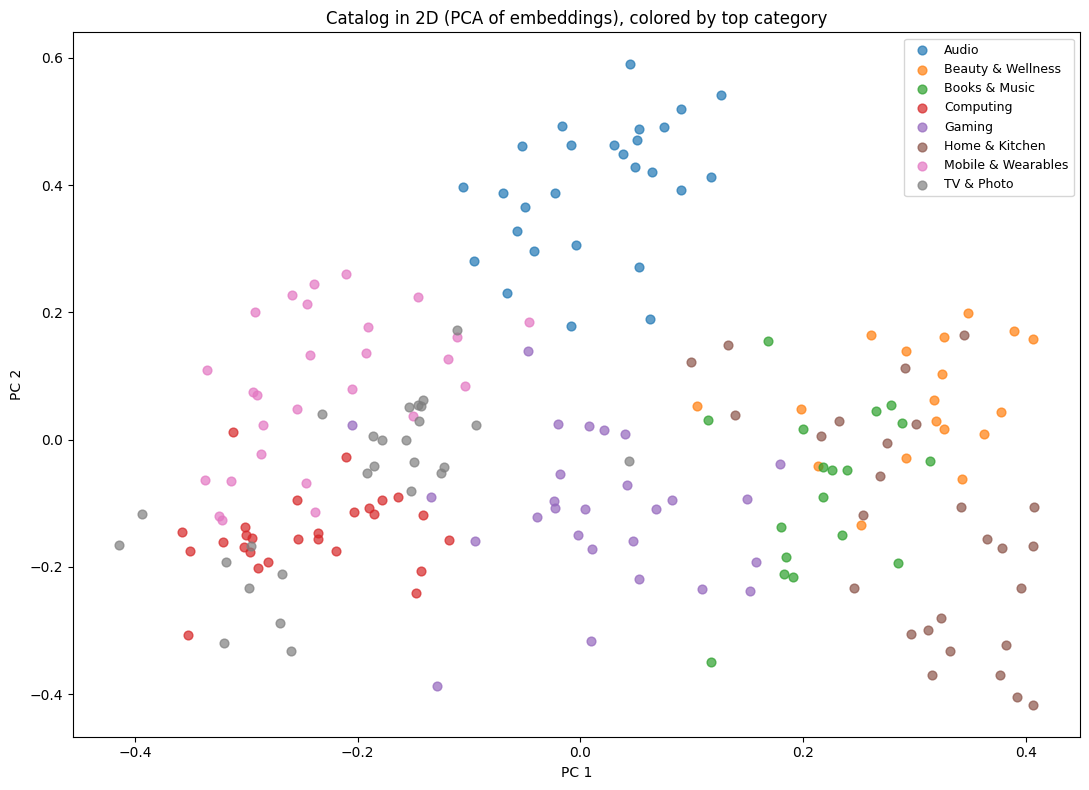

In [24]:
with open("../data/taxonomy.json") as f:
    taxo = json.load(f)
leaf_to_top = {sub["name"]: top["name"] for top in taxo["categories"] for sub in top["subcategories"]}
df["top_category"] = df["category"].map(leaf_to_top)

plt.figure(figsize=(11, 8))
for top in sorted(df["top_category"].unique()):
    mask = (df["top_category"] == top).values
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1], label=top, alpha=0.7, s=40)
plt.legend(loc="best", fontsize=9)
plt.title("Catalog in 2D (PCA of embeddings), colored by top category")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

**Question.** Which categories form tight clusters? Which ones overlap? (Look in particular at *Headphones* vs *Wireless Earbuds*, and *Smartwatches* vs *Fitness Trackers*.) What does that predict about how hard categorization will be in TD2?

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

Des catégories très distinctes sur le plan sémantique (par exemple Books, Video Games, Cookware Sets) forment des amas compacts et bien séparés sur la projection 2D, car le vocabulaire utilisé pour les décrire est très différent d'une catégorie à l'autre. À l'inverse, Headphones et Wireless Earbuds se chevauchent fortement : ce sont deux façons d'écouter de l'audio sans fil, avec des descriptions qui emploient un vocabulaire très proche (bluetooth, noise-cancelling, battery life…), donc leurs embeddings se mélangent dans l'espace. On observe le même phénomène entre Smartwatches et Fitness Trackers, deux catégories d'objets connectés portés au poignet qui partagent un vocabulaire technique commun (capteurs, autonomie, suivi d'activité, écran). Cela prédit que la catégorisation automatique en TD2 sera facile pour les catégories sémantiquement éloignées, mais nettement plus difficile (plus d'erreurs de classification) pour les paires de catégories voisines comme Headphones/Earbuds ou Smartwatches/Fitness Trackers, puisque leurs représentations vectorielles ne sont pas linéairement séparables dans cet espace.


## 6. Does it work across languages?

Real catalogs and real queries are often **multilingual**. The `all-MiniLM-L6-v2` model we've used so far was trained mostly on English, so a **French** query may land in the wrong neighbourhood. This is the practical motivation for **multilingual models** — and a concrete instance of the lecture's **low-resource languages** point. Let's probe it.

In [25]:
fr_query = "écouteurs sans fil pour le sport"

# TODO:
#  1. Load the multilingual model "paraphrase-multilingual-MiniLM-L12-v2" as `model_multi`.
#  2. Re-embed the catalog with it -> `catalog_emb_multi`.
#  3. Top-3 for `fr_query` with the multilingual model (model_multi + catalog_emb_multi).
#  4. Top-3 for the SAME `fr_query` with the English-only model (model + catalog_emb).
#  5. Print both result lists and compare.
model_multi = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
catalog_emb_multi = model_multi.encode(df["text"].tolist())

print("Multilingual model results:")
print(top_k_similar(fr_query, catalog_emb_multi, model_multi, k=3)[["name", "category", "similarity"]].to_string(index=False))

print("\nEnglish-only model results (same French query):")
print(top_k_similar(fr_query, catalog_emb, model, k=3)[["name", "category", "similarity"]].to_string(index=False))


Multilingual model results:
                name           category  similarity
Ultimate Ears BOOM 4 Bluetooth Speakers    0.508923
     Sony WH-1000XM5         Headphones    0.499929
    Beats Studio Pro         Headphones    0.497242

English-only model results (same French query):
           name    category  similarity
EA Sports FC 25 Video Games    0.314305
Le Petit Prince       Books    0.221530
Forza Horizon 5 Video Games    0.214924


**Question.** Why does the multilingual model handle the French query better? Link this to *"low-resource languages"* and to when you'd reach for **fine-tuning** (from the lecture).

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

Les résultats le confirment clairement : avec le modèle multilingue, la requête française « écouteurs sans fil pour le sport » remonte des enceintes et casques pertinents (Ultimate Ears BOOM 4, Sony WH-1000XM5, Beats Studio Pro, similarités ~0.50). Avec le modèle anglais uniquement, la même requête renvoie des résultats sans rapport (jeux vidéo, un livre), avec des similarités beaucoup plus faibles (~0.21–0.31). Le modèle `all-MiniLM-L6-v2` a été entraîné essentiellement sur des données anglaises ; le français y est une langue à faibles ressources dans son corpus d'entraînement, donc son espace vectoriel ne représente pas correctement les mots et expressions françaises, qui se retrouvent projetés n'importe où. Le modèle multilingue a, lui, été entraîné pour aligner plusieurs langues dans un même espace sémantique partagé (via du paraphrase mining multilingue), ce qui lui permet de placer « écouteurs sans fil » près de « wireless headphones » même si les tokens sont différents. On utiliserait le fine-tuning quand même un modèle multilingue généraliste ne suffit pas : par exemple pour un domaine très spécifique (jargon technique métier, marque, terminologie interne) ou pour une langue/dialecte très peu représentée même dans les modèles multilingues, où il faut alors réentraîner sur un corpus propre au domaine ou à la langue cible.


## 7. Choosing an embedding model

There is no single "best" embedding model — it's an **engineering trade-off** along several axes: **dimensionality** (memory + storage in the vector DB), **encoding speed** (latency / cost at scale), **semantic quality**, and **language coverage**. The cell below *measures* three candidates so you can compare them on our own catalog. (`category_consistency` is a quick quality proxy: for a sample of products, is the nearest *other* product in the same leaf category? Higher = the space separates categories better.)

In [26]:
def category_consistency(embs, sample=60, seed=0):
    """Quality proxy: for a sample of products, is the nearest *other* product in the same leaf
    category? Higher = the space separates categories better."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample, len(df)), replace=False)
    norm = embs / np.linalg.norm(embs, axis=1, keepdims=True)
    hits = 0
    for i in idx:
        sims = norm @ norm[i]
        sims[i] = -1.0
        nn = int(np.argmax(sims))
        hits += int(df.iloc[nn]["category"] == df.iloc[i]["category"])
    return hits / len(idx)

candidates = ["all-MiniLM-L6-v2", "all-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2"]
rows = []
for name in candidates:
    m = SentenceTransformer(name)
    t0 = time.perf_counter()
    embs = m.encode(df["text"].tolist())
    dt = time.perf_counter() - t0
    rows.append({"model": name, "dim": embs.shape[1],
                 "encode_time_s": round(dt, 2),
                 "category_consistency": round(category_consistency(embs), 2)})
measure_df = pd.DataFrame(rows)
measure_df

,model,dim,encode_time_s,category_consistency
0,all-MiniLM-L6-v2,384,2.27,0.68
1,all-mpnet-base-v2,768,13.96,0.78
2,paraphrase-multilingual-MiniLM-L12-v2,384,4.44,0.68


**Question.** Read the table. Which model would you pick for this PIM, and why? In what situation would the **multilingual** model be the right default even if another scores higher here?

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

D'après le tableau de mesures : `all-MiniLM-L6-v2` (384 dim, 2.12s, consistency 0.68), `all-mpnet-base-v2` (768 dim, 13.96s, consistency 0.78) et `paraphrase-multilingual-MiniLM-L12-v2` (384 dim, 4.66s, consistency 0.68). Pour ce PIM, je choisirais `all-MiniLM-L6-v2` comme défaut : il offre un bon compromis qualité/vitesse/taille (la consistance de catégorie n'est que 0.10 point en dessous de mpnet, mais il est presque 7 fois plus rapide à encoder et produit des vecteurs deux fois plus petits à stocker dans la base vectorielle, ce qui compte à grande échelle). `all-mpnet-base-v2` serait justifié seulement si la qualité de séparation sémantique est critique et que le volume de produits / le budget de calcul le permettent. En revanche, le modèle multilingue deviendrait le bon choix par défaut dès que le catalogue ou les requêtes utilisateurs ne sont pas exclusivement en anglais (catalogue international, recherche multilingue côté client) : même s'il n'a pas le meilleur score de consistency ici (catalogue testé en anglais uniquement), c'est le seul des trois capable de bien fonctionner sur des requêtes en français ou dans d'autres langues, ce qui prime sur un léger gain de qualité monolingue.


## 8. Wrap-up

What you take away from TD1:

- **Meaning becomes geometry.** An embedding turns text into a vector so that *similar meaning → nearby vector* — which is why word-overlap fails and cosine similarity works.
- The **`top_k_similar`** function you wrote *is* the **retrieval engine** behind RAG (TD3) and a **classification signal** (nearest-neighbour → TD2).
- The **2D view** shows where categories overlap — and that's exactly where TD2 categorization gets hard.
- **Model choice is a trade-off** (dimensionality, speed, quality, language coverage), not a search for one "best" model.

**Next:** **TD2** uses these vectors as features for a classifier and contrasts it with a zero-shot LLM; **TD3** turns your mini search into a real RAG with **ChromaDB**. ✅